## Chaotic Pendulum

In [2]:
import mujoco
import time 
import numpy as np
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()

""

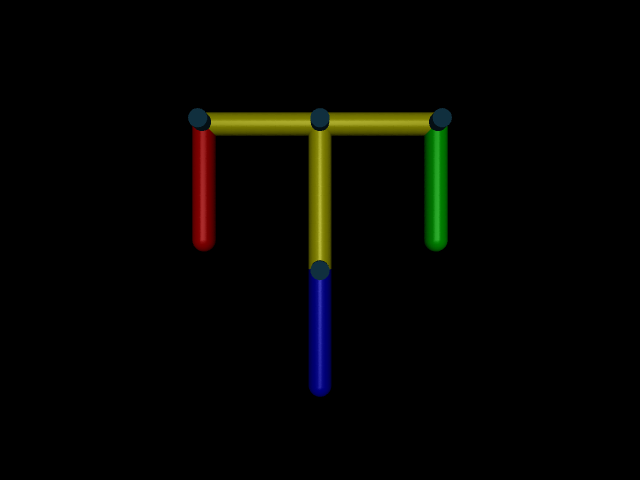

In [3]:
model = mujoco.MjModel.from_xml_path("chaotic_pendulum.xml")
data = mujoco.MjData(model)
height = 480
width = 640

# turn on joint visualization
scene_option = mujoco.MjvOption()
scene_option.flags[mujoco.mjtVisFlag.mjVIS_JOINT] = True

with mujoco.Renderer(model, height, width) as renderer:
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera="fixed", scene_option=scene_option)

    media.show_image(renderer.render())

In [4]:
# setup for creating a video and timing components
n_seconds = 6 # seconds
framerate = 30 # HZ
n_frames = int(n_seconds * framerate)
frames = []
height = 240
width = 320

# set the initial state
mujoco.mj_resetData(model,data)
data.joint('root').qvel = 10

# simulate and record frames
frame = 0
sim_time = 0
render_time = 0
n_steps = 0

with mujoco.Renderer(model, height, width) as renderer:
    for i in range(n_frames):
        for i in range(n_frames):
            while data.time*framerate < i:
                tic = time.time()
                mujoco.mj_step(model, data)
                sim_time += time.time() - tic
                n_steps +=1
            tic = time.time()
            renderer.update_scene(data, camera="fixed")
            frame = renderer.render()
            render_time += time.time() - tic
            frames.append(frame)

# print timing and play video
step_time = 1e6*sim_time/n_steps
step_fps = n_steps/sim_time
print(f'simulation: {step_time:5.3g} us/step ({step_fps:5.0f}Hz)')
frame_time =1e6*render_time/n_frames
frame_fps = n_frames/render_time
print(f'rendering: {frame_time:5.3g} us/frame ({frame_fps:5.0f}Hz)')
print('\n')

# play the video
media.show_video(frames, fps=framerate)



simulation:  2.95 us/step (338565Hz)
rendering: 6.96e+04 us/frame (   14Hz)




This browser does not support the video tag.


/tmp/ipykernel_40232/1231484931.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  angle[i] = data.joint('root').qpos


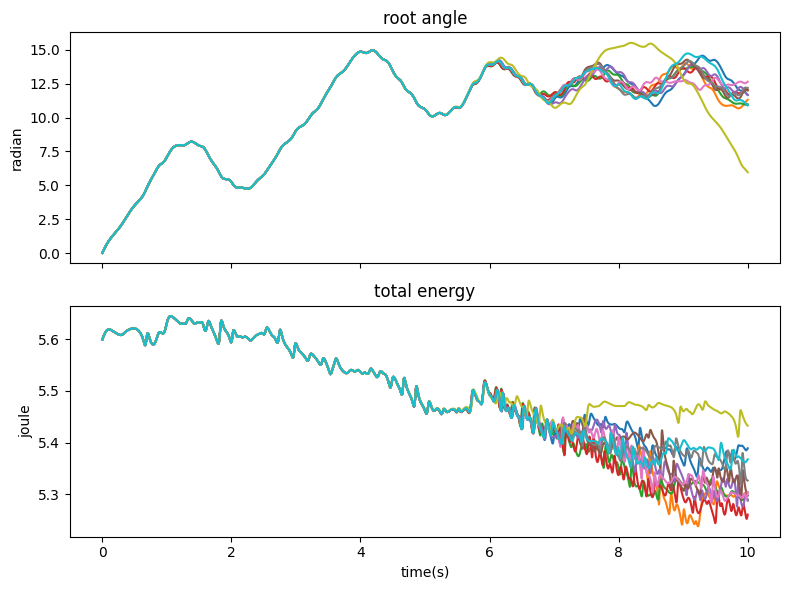

In [5]:
# chaos
PERTURBATION = 1e-7
SIM_DURATION = 10 # seconds
NUM_REPEATS = 10

# preallocate
n_steps = int(SIM_DURATION / model.opt.timestep)
sim_time = np.zeros(n_steps)
angle = np.zeros(n_steps)
energy = np.zeros(n_steps)

# prepare plotting axes
_, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# simulate NUM_REPEATS times with slightly different initial conditions
for _ in range(NUM_REPEATS):
    # initialize
    mujoco.mj_resetData(model, data)
    data.qvel[0] = 10 # root joint velocity
    # perturb the initial velocitys
    data.qvel[:] += PERTURBATION * np.random.randn(model.nv)

    #simulate
    for i in range(n_steps):
        mujoco.mj_step(model, data)
        sim_time[i] = data.time
        angle[i] = data.joint('root').qpos
        energy[i] = data.energy[0] + data.energy[1]

    # plot
    ax[0].plot(sim_time, angle)
    ax[1].plot(sim_time, energy)

# finalize plot
ax[0].set_title('root angle')
ax[0].set_ylabel('radian')
ax[1].set_title('total energy')
ax[1].set_ylabel('joule')
ax[1].set_xlabel('time(s)')
plt.tight_layout()

